# LSTM — PM2.5 Tashkent
Step-by-step: load data → scale → sequences → train → metrics → plots → save

> **Muhim:** TensorFlow Python 3.12 da ishlaydi. Agar xato chiqsa:
> ```
> py -3.12 -m pip install tensorflow-cpu
> ```
> va ushbu notebookni Python 3.12 kernel da oching.

## 1. Imports and configuration

In [1]:
import json
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

BASE       = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR   = os.path.join(BASE, 'data')
MODELS_DIR = os.path.join(BASE, 'models')
OUT_DIR    = os.path.join(BASE, 'outputs', 'lstm_ipynb_analysis')

SEQ_LEN = 24  # 24-hour input window

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUT_DIR,    exist_ok=True)

print('Ready.')
print(f'Output folder: {OUT_DIR}')

Ready.
Output folder: c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\outputs\lstm_ipynb_analysis


## 2. Check TensorFlow

In [2]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    print(f'TensorFlow version: {tf.__version__}')
    print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
except ImportError as e:
    print(f'ERROR: {e}')
    print('Install: pip install tensorflow-cpu')
    raise

TensorFlow version: 2.21.0
GPU available: False


## 3. Load data

In [3]:
train = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'), parse_dates=['datetime'])
test  = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'),  parse_dates=['datetime'])

with open(os.path.join(DATA_DIR, 'feature_cols.json')) as f:
    feature_cols = json.load(f)

print(f'Train : {train.shape}')
print(f'Test  : {test.shape}')
print(f'Features: {len(feature_cols)}')

Train : (16928, 28)
Test  : (4233, 28)
Features: 25


## 4. Target (PM2.5) statistics

In [4]:
print('=== Train PM2.5 statistics ===')
print(train['pm25'].describe().round(2))
print('\n=== Test PM2.5 statistics ===')
print(test['pm25'].describe().round(2))

=== Train PM2.5 statistics ===
count    16928.00
mean        32.03
std         38.29
min          0.00
25%          9.30
50%         17.00
75%         38.51
max        249.21
Name: pm25, dtype: float64

=== Test PM2.5 statistics ===
count    4233.00
mean       25.23
std        25.12
min         0.25
25%        10.70
50%        16.80
75%        27.80
max       224.95
Name: pm25, dtype: float64


## 5. Split features and target

In [5]:
X_train_raw = train[feature_cols].values
y_train     = train['pm25'].values
X_test_raw  = test[feature_cols].values
y_test      = test['pm25'].values

print(f'X_train : {X_train_raw.shape}')
print(f'X_test  : {X_test_raw.shape}')
print(f'NaN check — train: {np.isnan(X_train_raw).sum()}, test: {np.isnan(X_test_raw).sum()}')

X_train : (16928, 25)
X_test  : (4233, 25)
NaN check — train: 0, test: 0


## 6. Scale features

LSTM is sensitive to feature scale. StandardScaler is fit only on training data to prevent data leakage.

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

scaler_path = os.path.join(MODELS_DIR, 'lstm_scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved => {scaler_path}')

print(f'\nFeature means (first 5): {scaler.mean_[:5].round(3)}')
print(f'Feature stds  (first 5): {scaler.scale_[:5].round(3)}')

Scaler saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\models\lstm_scaler.pkl

Feature means (first 5): [ 16.356  52.437   6.906 187.55  963.701]
Feature stds  (first 5): [ 11.91   25.818   3.945 113.845   7.076]


## 7. Create sequences

LSTM needs 3D input: `(samples, SEQ_LEN, n_features)`. Each sample contains the last 24 hours of features.

In [7]:
def make_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i - seq_len:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_tr_seq, y_tr_seq = make_sequences(X_train_sc, y_train, SEQ_LEN)
X_te_seq, y_te_seq = make_sequences(X_test_sc,  y_test,  SEQ_LEN)

print(f'Train sequences : {X_tr_seq.shape}  ->  targets: {y_tr_seq.shape}')
print(f'Test  sequences : {X_te_seq.shape}  ->  targets: {y_te_seq.shape}')

Train sequences : (16904, 24, 25)  ->  targets: (16904,)
Test  sequences : (4209, 24, 25)  ->  targets: (4209,)


## 8. Build LSTM model

In [8]:
n_features = X_tr_seq.shape[2]

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, n_features)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1),
])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\LENOVO\Desktop\Project 2.5\lstm_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        78,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,369 (509.25 KB)

 Trainable params: 130,369 (509.25 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train LSTM

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

print(f'Training LSTM... (max 50 epochs, early stop patience=5)')
t0 = time.time()
history = model.fit(
    X_tr_seq, y_tr_seq,
    validation_data=(X_te_seq, y_te_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1,
)
elapsed = time.time() - t0
print(f'\nDone. Time: {elapsed:.1f}s  |  Epochs run: {len(history.history["loss"])}')

Training LSTM... (max 50 epochs, early stop patience=5)
Epoch 1/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 1464.2881 - val_loss: 223.4160
Epoch 2/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 432.5692 - val_loss: 127.6304
Epoch 3/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step - loss: 331.5003 - val_loss: 116.2974
Epoch 4/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - loss: 311.4556 - val_loss: 121.9802
Epoch 5/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 300.5849 - val_loss: 114.6718
Epoch 6/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 22s 82ms/step - loss: 283.7090 - val_loss: 133.2370
Epoch 7/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - loss: 274.1277 - val_loss: 121.1506
Epoch 8/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - loss: 266.2654 - val_loss: 127.9141
Epoch 9/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - loss: 250.9224 - val_loss: 120.6601
Epoch 10/50
265/265 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - loss: 237.2971 - val_loss: 134.4710
Epoch 10: early stoppin

## 10. Training loss curve

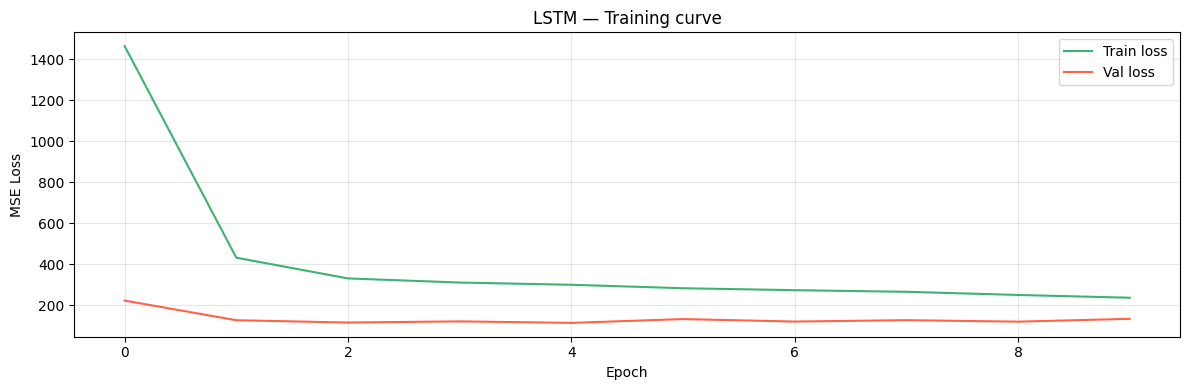

Best epoch     : 5
Best val loss  : 114.6718


In [10]:
plt.figure(figsize=(12, 4))
plt.plot(history.history['loss'],     label='Train loss', color='mediumseagreen')
plt.plot(history.history['val_loss'], label='Val loss',   color='tomato')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM — Training curve')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '01_training_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

best_epoch = np.argmin(history.history['val_loss'])
print(f'Best epoch     : {best_epoch + 1}')
print(f'Best val loss  : {history.history["val_loss"][best_epoch]:.4f}')

## 11. Predictions and metrics

In [11]:
y_pred_train = model.predict(X_tr_seq, verbose=0).flatten()
y_pred_test  = model.predict(X_te_seq, verbose=0).flatten()

rmse_train = np.sqrt(mean_squared_error(y_tr_seq, y_pred_train))
mae_train  = mean_absolute_error(y_tr_seq, y_pred_train)
r2_train   = r2_score(y_tr_seq, y_pred_train)

rmse_test  = np.sqrt(mean_squared_error(y_te_seq, y_pred_test))
mae_test   = mean_absolute_error(y_te_seq, y_pred_test)
r2_test    = r2_score(y_te_seq, y_pred_test)

print('=' * 42)
print(f'{"Metric":<12} {"Train":>12} {"Test":>12}')
print('-' * 42)
print(f'{"RMSE":<12} {rmse_train:>12.3f} {rmse_test:>12.3f}')
print(f'{"MAE":<12} {mae_train:>12.3f} {mae_test:>12.3f}')
print(f'{"R2":<12} {r2_train:>12.4f} {r2_test:>12.4f}')
print('=' * 42)

print(f'\nTarget: R2 > 0.88')
print(f'R2 test : {r2_test:.4f} => {"PASS" if r2_test > 0.88 else "FAIL"}')

Metric              Train         Test
------------------------------------------
RMSE               16.338       10.708
MAE                 9.027        6.049
R2                 0.8179       0.8166

Target: R2 > 0.88
R2 test : 0.8166 => FAIL


## 12. Actual vs Predicted plots

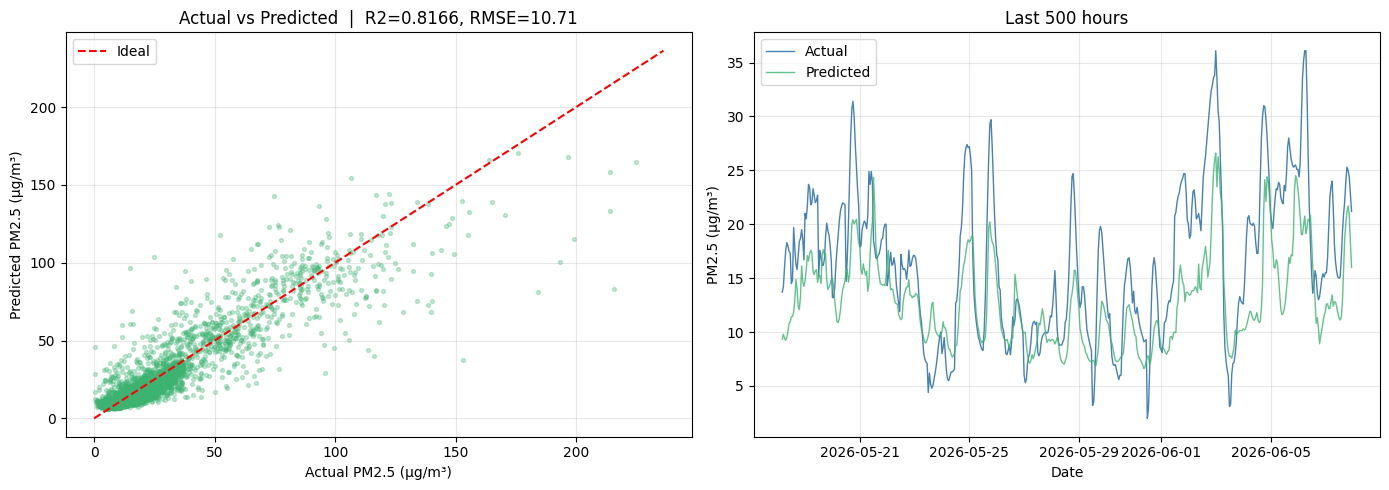

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_te_seq, y_pred_test, alpha=0.3, s=8, color='mediumseagreen')
lim_max = max(y_te_seq.max(), y_pred_test.max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], 'r--', linewidth=1.5, label='Ideal')
ax.set_xlabel('Actual PM2.5 (µg/m³)')
ax.set_ylabel('Predicted PM2.5 (µg/m³)')
ax.set_title(f'Actual vs Predicted  |  R2={r2_test:.4f}, RMSE={rmse_test:.2f}')
ax.legend()

ax = axes[1]
n = 500
test_dates = test['datetime'].iloc[SEQ_LEN:]
ax.plot(test_dates.iloc[-n:], y_te_seq[-n:],      label='Actual',    linewidth=1, color='steelblue')
ax.plot(test_dates.iloc[-n:], y_pred_test[-n:],   label='Predicted', linewidth=1, color='mediumseagreen', alpha=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('Last 500 hours')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '02_actual_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Residuals analysis

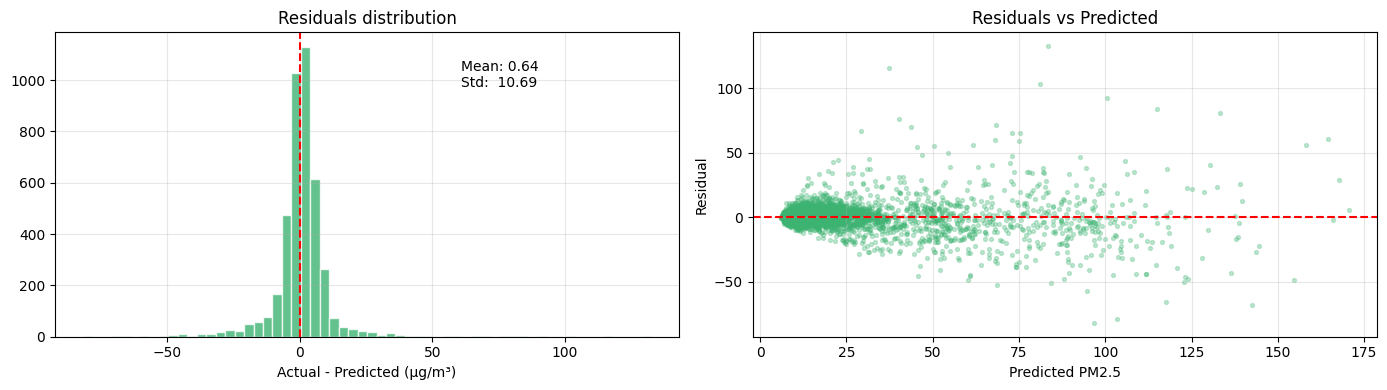

Mean : 0.643  (should be close to 0)
Std  : 10.689
Min  : -81.783
Max  : 132.473


In [13]:
residuals = y_te_seq - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(residuals, bins=60, color='mediumseagreen', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals distribution')
axes[0].set_xlabel('Actual - Predicted (µg/m³)')
axes[0].annotate(f'Mean: {residuals.mean():.2f}\nStd:  {residuals.std():.2f}',
                 xy=(0.65, 0.82), xycoords='axes fraction', fontsize=10)

axes[1].scatter(y_pred_test, residuals, alpha=0.3, s=8, color='mediumseagreen')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '03_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean : {residuals.mean():.3f}  (should be close to 0)')
print(f'Std  : {residuals.std():.3f}')
print(f'Min  : {residuals.min():.3f}')
print(f'Max  : {residuals.max():.3f}')

## 14. Largest prediction errors

In [14]:
test_dates_seq = test['datetime'].iloc[SEQ_LEN:].reset_index(drop=True)
error_df = pd.DataFrame({
    'datetime':  test_dates_seq,
    'actual':    y_te_seq,
    'predicted': y_pred_test,
    'error':     np.abs(residuals),
})

big_errors = error_df.nlargest(10, 'error')[['datetime', 'actual', 'predicted', 'error']]
big_errors.columns = ['Date', 'Actual', 'Predicted', 'Abs Error']
big_errors = big_errors.round(2)

print('Top 10 largest prediction errors:')
print(big_errors.to_string(index=False))

Top 10 largest prediction errors:
                     Date  Actual  Predicted  Abs Error
2026-01-09 06:00:00+00:00  215.82  83.349998     132.47
2026-01-10 20:00:00+00:00  152.93  37.230000     115.70
2025-12-19 07:00:00+00:00  184.11  81.209999     102.90
2025-12-19 08:00:00+00:00  193.17 100.510002      92.67
2025-12-19 18:00:00+00:00  199.05 114.959999      84.09
2025-12-21 23:00:00+00:00   15.00  96.779999      81.78
2025-12-19 19:00:00+00:00  214.24 133.199997      81.04
2026-01-02 16:00:00+00:00   24.96 103.360001      78.40
2026-01-15 09:00:00+00:00  116.29  40.270000      76.01
2025-12-25 01:00:00+00:00  139.73  68.279999      71.44


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6188\3431658544.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  big_errors = big_errors.round(2)


## 15. Monthly RMSE breakdown

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6188\957208454.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  error_df['month'] = error_df['datetime'].dt.to_period('M')


Monthly metrics:
  month  RMSE   MAE      R2     n
2025-12 22.28 15.94  0.7124 417.0
2026-01 16.53 10.74  0.6813 744.0
2026-02  4.58  3.63  0.6307 672.0
2026-03  6.14  4.05  0.5543 744.0
2026-04  3.56  2.72  0.5469 720.0
2026-05  4.00  3.15  0.5379 744.0
2026-06  7.39  6.30 -0.0916 168.0


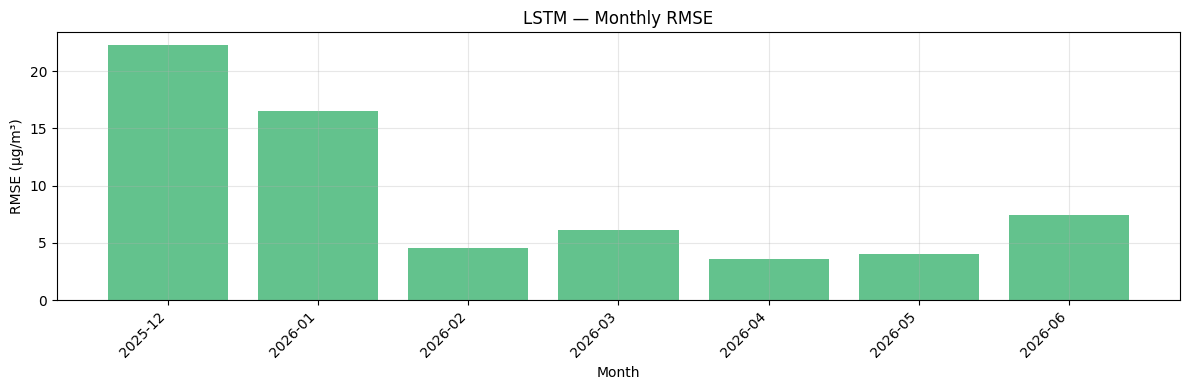

In [15]:
error_df['month'] = error_df['datetime'].dt.to_period('M')
monthly = error_df.groupby('month').apply(
    lambda g: pd.Series({
        'RMSE': round(np.sqrt(mean_squared_error(g['actual'], g['predicted'])), 2),
        'MAE':  round(mean_absolute_error(g['actual'], g['predicted']), 2),
        'R2':   round(r2_score(g['actual'], g['predicted']), 4) if len(g) > 1 else None,
        'n':    len(g),
    })
).reset_index()

print('Monthly metrics:')
print(monthly.to_string(index=False))

plt.figure(figsize=(12, 4))
plt.bar(monthly['month'].astype(str), monthly['RMSE'], color='mediumseagreen', alpha=0.8)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Month')
plt.ylabel('RMSE (µg/m³)')
plt.title('LSTM — Monthly RMSE')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, '04_monthly_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Save model, scaler, and metrics

In [16]:
model_path = os.path.join(MODELS_DIR, 'lstm.keras')
model.save(model_path)
print(f'Model saved  => {model_path}')
print(f'Scaler saved => {scaler_path}  (already saved in step 6)')

metrics = {
    'model': 'LSTM',
    'train': {'rmse': round(rmse_train, 4), 'mae': round(mae_train, 4), 'r2': round(r2_train, 4)},
    'test':  {'rmse': round(rmse_test,  4), 'mae': round(mae_test,  4), 'r2': round(r2_test,  4)},
    'params': {
        'seq_len': SEQ_LEN,
        'lstm_units': [128, 64],
        'dropout': 0.2,
        'dense': 32,
        'optimizer': 'adam',
        'epochs_run': len(history.history['loss']),
        'batch_size': 64,
    },
    'train_time_sec': round(elapsed, 1),
}

metrics_path = os.path.join(OUT_DIR, 'lstm_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved => {metrics_path}')

print('\n=== FINAL RESULTS ===')
print(f'  RMSE : {rmse_test:.3f}')
print(f'  MAE  : {mae_test:.3f}')
print(f'  R2   : {r2_test:.4f}')

Model saved  => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\models\lstm.keras
Scaler saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\models\lstm_scaler.pkl  (already saved in step 6)
Metrics saved => c:\Users\LENOVO\Desktop\Project 2.5\pm25_project\service1\outputs\lstm_ipynb_analysis\lstm_metrics.json

=== FINAL RESULTS ===
  RMSE : 10.708
  MAE  : 6.049
  R2   : 0.8166
